(00-01-rendementen)=

# Rendementen en hun statistiek

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1926–2026 — geen tijdvak maar een meetlat, gebouwd om de rest van
de reeks mee te kunnen wegen.

**Wat we al weten.** [De vorige lecture](#00-00-setup) zette de
gereedschapskist neer: acht gratis databronnen, een notatie, en een handvol
schatters. Ze eindigde met één getal dat de hele reeks zal achtervolgen — het
gemiddelde marktrendement over honderd jaar is 11,6% per jaar met een
standaardfout van 1,8 procentpunt — en met de bekentenis dat we daar "rendement"
hebben opgeteld en gemiddeld zonder ooit te zeggen wat een rendement is. Er ligt
dus een machine klaar waarvan de eenheden nog niet vaststaan.

**Welke vraag staat open.** Wat meten we precies als we een gemiddeld rendement
uitrekenen, en hoe nauwkeurig is die meting?
```

## Overzicht

Deze lecture gaat over de meetlat zelf. Ze heeft geen jaartal en geen held: wat
hier staat was in 1926 al bekend bij statistici, en het is in 2026 nog steeds de
reden dat de belangrijkste grootheid van het vak niet gemeten kan worden. De
inhoud is elementair — een logaritme, een wortel, een steekproefvariantie — en
juist daarom loont het de moeite hem één keer volledig uit te schrijven. Bijna
elke controverse verderop in de reeks, van de equity premium puzzle tot de
factor zoo, is een gevecht over een grootheid waarvan de standaardfout in deze
lecture wordt uitgerekend.

Drie dingen worden hier vastgelegd. Ten eerste het verschil tussen simpele en
log-rendementen, en wanneer welk van de twee het juiste antwoord op uw vraag is:
het rekenkundig gemiddelde meet wat u volgend jaar verwacht, het meetkundig
gemiddelde meet wat er over honderd jaar in de rekening staat. Het verschil
tussen die twee heet *variance drag* (de rem die volatiliteit op samengestelde
groei zet: hoe meer een reeks schommelt, hoe verder het eindvermogen
achterblijft bij het gemiddelde rendement) en is geen afrondingsfout maar een
halve variantie. Ten tweede de wortel-$t$-regel: waarom volatiliteit met $\sqrt{t}$
schaalt, wat daarvoor nodig is (onafhankelijkheid), en wat er gebeurt als die
aanname niet klopt. Ten derde, en dat is de hoofdzaak, de standaardfout van het
gemiddelde.

Dat derde punt heeft een precieze vorm die het waard is vooruit te noemen. Het
gemiddelde rendement is een *drift*, en de nauwkeurigheid waarmee u een drift
schat hangt uitsluitend af van de kalenderlengte van uw steekproef, niet van hoe
fijn u binnen die periode meet. De variantie is daarentegen een *quadratische
variatie*, en die wordt wél nauwkeuriger naarmate u vaker kijkt. Dat inzicht is
scherp geformuleerd door {cite:t}`Merton1980`, en het is de wiskundige kern van
wat in deze reeks het 2%-motief heet: honderd jaar geschiedenis zijn honderd
trekkingen, ongeacht of u ze maandelijks of per minuut opschrijft.

We repliceren het eerste getal dat er ooit was. In 1964 rapporteerden Lawrence
Fisher en James Lorie op de verse CRSP-tape het gemiddelde rendement op
Amerikaanse aandelen over 1926–1960 {cite}`FisherLorie1964`. Hun antwoord, 9,0%
per jaar met herbelegde dividenden, was de eerste betrouwbare meting van de
grootheid en staat nog steeds in leerboeken. We bouwen hem na op de
French-data, en zetten er iets bij wat in het originele artikel ontbreekt: de
standaardfout.

De epistemische status van deze lecture is bijzonder. Er staat geen theorie in
die getoetst kan worden — het is meettheorie, en de stellingen zijn waar omdat
ze wiskundig waar zijn. Maar ze bepaalt wél welke latere theorieën *toetsbaar*
zijn, en het antwoord op die vraag is vaker "geen" dan het vak lief is.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Stel dat u wilt weten hoe hard het gemiddeld waait op een bepaalde plek. U zet
er een meetpaal neer. Twee vragen kunt u stellen. De eerste: hoeveel lucht is er
in totaal langsgekomen? De tweede: hoe hard schommelt de wind?

Voor de eerste vraag maakt het niet uit hoe vaak u meet. Als u elke seconde
meet in plaats van elk uur, krijgt u driehonderdzestig keer zoveel getallen,
maar u meet nog steeds dezelfde lucht. Het totaal dat langskomt tussen januari
en december is één getal, en dat getal staat vast zodra het jaar voorbij is. Wilt
u het gemiddelde beter kennen, dan moet u langer meten — meer jaren, niet meer
metingen per jaar.

Voor de tweede vraag ligt het omgekeerd. De schommeling zit *in* de metingen: elke
extra waarneming is een extra stukje informatie over hoe onrustig het is. Meet u
per seconde in plaats van per uur, dan kent u de onrust van dat ene jaar
ineens bijna exact. Eén jaar seconde-data zegt meer over de volatiliteit dan een
eeuw jaardata.

Aandelenrendementen zijn wind. Het gemiddelde rendement is de totale afgelegde
afstand gedeeld door de tijd, en die afstand hangt alleen af van waar de prijs
begon en waar hij eindigde. Meet u dagelijks in plaats van jaarlijks, dan hebt u
tweehonderdvijftig keer zoveel getallen en precies evenveel informatie over het
gemiddelde: de som van de dagelijkse logrendementen ís het jaarlijkse
logrendement. De volatiliteit daarentegen wordt bij elke verfijning scherper.

Daar komt een tweede ongelijkheid bij die niets met meten te maken heeft maar
met rekenen. Verlies van 20% en winst van 25% heffen elkaar op in *niveaus*
($0{,}80 \times 1{,}25 = 1$) maar niet in *gemiddelden*: het rekenkundig
gemiddelde van $-20\%$ en $+25\%$ is $+2{,}5\%$, terwijl uw vermogen onveranderd
is. Rendementen vermenigvuldigen zich, gemiddelden tellen op, en het verschil
tussen die twee operaties groeit met de variantie. Wie een gemiddeld rendement
noemt zonder te zeggen welk van de twee hij bedoelt, kan er in een eeuw makkelijk
een factor tien naast zitten.

Beide observaties zijn oud en geen van beide is diep. Wat ze diep maakt is hun
combinatie met de getallen van de echte wereld. De volatiliteit van aandelen is
ongeveer 20% per jaar en de premie ongeveer 6%; de ruis is dus meer dan drie keer
zo groot als het signaal, en het signaal kan alleen door tijd te laten verstrijken
zichtbaar worden. In de negentig jaar sinds er data is, is dat drie keer
verdubbeld — en de premie is nog altijd niet nauwkeuriger bekend dan op een paar
procentpunt.

## Toy-voorbeeld: drie jaar rendement, met de hand

Een belegging doet in drie jaar achtereenvolgens $+25\%$, $-20\%$ en $+10\%$.
Alles wat verderop in deze lecture staat, is al zichtbaar in deze drie getallen.

**Het rekenkundig gemiddelde.** Optellen en delen door drie:

$$
\bar r = \frac{0{,}25 - 0{,}20 + 0{,}10}{3} = \frac{0{,}15}{3} = 0{,}05 .
$$

Vijf procent per jaar.

**Het meetkundig gemiddelde.** De bruto rendementen zijn $1{,}25$, $0{,}80$ en
$1{,}10$. Hun product is $1{,}25 \times 0{,}80 = 1{,}00$, en dat maal $1{,}10$
geeft $1{,}10$. Eén euro is dus na drie jaar $1{,}10$ euro geworden, en het
meetkundig gemiddelde is

$$
\bar R_g = 1{,}10^{1/3} = 1{,}032280, \qquad \text{dus } 3{,}2280\% \text{ per jaar.}
$$

Het verschil met het rekenkundig gemiddelde is $5 - 3{,}2280 = 1{,}772$
procentpunt. Dat is geen afrondingsfout: over dertig jaar is het het verschil
tussen $1{,}05^{30} = 4{,}32$ en $1{,}0323^{30} = 2{,}59$, bijna een factor twee.

**De logrendementen.** Met $\log 1{,}25 = 0{,}223144$,
$\log 0{,}80 = -0{,}223144$ en $\log 1{,}10 = 0{,}095310$ vallen de eerste twee
tegen elkaar weg — dat is de hele inhoud van "20% verlies is geen 20% winst
terug". De som is $0{,}095310$, het gemiddelde $0{,}031770$, en

$$
e^{0{,}031770} - 1 = 0{,}032280 .
$$

Exact het meetkundig gemiddelde. Het gemiddelde logrendement *is* het
meetkundig gemiddelde, in een andere schrijfwijze.

**De variance drag.** De afwijkingen van $\bar r = 0{,}05$ zijn $0{,}20$,
$-0{,}25$ en $0{,}05$; hun kwadraten $0{,}04$, $0{,}0625$ en $0{,}0025$ tellen
op tot $0{,}105$. Gedeeld door $3$ geeft dat $\hat\sigma^2 = 0{,}035$, en de
halve variantie is $0{,}0175$. Trekken we die van het rekenkundig gemiddelde af:

$$
0{,}05 - 0{,}0175 = 0{,}0325 ,
$$

tegen de exacte $0{,}032280$. De vuistregel "meetkundig $\approx$ rekenkundig
min een halve variantie" klopt hier tot op twee honderdste procentpunt, bij
slechts drie waarnemingen.

**De standaardfout.** Delen we de kwadratensom door $T-1 = 2$ in plaats van door
$3$, dan is $s^2 = 0{,}0525$ en $s = 0{,}229129$. De standaardfout van het
gemiddelde is

$$
\SD(\bar r) = \frac{s}{\sqrt{T}} = \frac{0{,}229129}{\sqrt{3}} = 0{,}132289 ,
$$

en de $t$-waarde van het gemiddelde is $0{,}05 / 0{,}132289 = 0{,}378$. Met drie
jaar data is een rendement van vijf procent per jaar statistisch niet van nul te
onderscheiden. Dat is te verwachten bij $T = 3$; de onaangename ontdekking van
deze lecture is dat het bij $T = 100$ nauwelijks beter wordt.

In [2]:
r = np.array([0.25, -0.20, 0.10])
gross = 1 + r

arith = r.mean()
geom = gross.prod() ** (1 / len(r)) - 1
log_returns = np.log(gross)
geom_via_log = np.exp(log_returns.mean()) - 1
drag_approx = arith - r.var(ddof=0) / 2
se = r.std(ddof=1) / np.sqrt(len(r))

pd.DataFrame(
    {
        "waarde": [arith, geom, geom_via_log, drag_approx, arith - geom,
                   r.std(ddof=1), se, arith / se],
    },
    index=["rekenkundig gemiddelde", "meetkundig gemiddelde",
           "via gemiddeld logrendement", "benadering: gem. - sigma^2/2",
           "variance drag (exact)", "standaarddeviatie (ddof=1)",
           "standaardfout van het gemiddelde", "t-waarde"],
).round(6)

,waarde
rekenkundig gemiddelde,0.050000
meetkundig gemiddelde,0.032280
via gemiddeld logrendement,0.032280
benadering: gem. - sigma^2/2,0.032500
variance drag (exact),0.017720
standaarddeviatie (ddof=1),0.229129
standaardfout van het gemiddelde,0.132288
t-waarde,0.377964


De tweede en de derde regel zijn tot op de laatste decimaal gelijk, en de vierde
ligt 0,00022 van de tweede af. De handberekening en de code zeggen hetzelfde; wat
hierna komt mag u daarom geloven.

## Theorie

### Twee soorten rendement, en waarvoor ze dienen

Laat $P_t$ de prijs zijn en $D_{t+1}$ het dividend dat tussen $t$ en $t+1$ wordt
uitgekeerd. Het *simpele* netto rendement en het bruto rendement zijn

```{math}
:label: eq-rendementen-simpel
r_{t+1} = \frac{P_{t+1} + D_{t+1}}{P_t} - 1,
\qquad
R_{t+1} = 1 + r_{t+1} = \frac{P_{t+1} + D_{t+1}}{P_t} .
```

Het *logrendement* (ook wel continu samengesteld rendement) is de logaritme
daarvan. De notatietabel in [](#00-00-setup) reserveert kleine letters voor
log-grootheden waar dat is aangekondigd, maar deze lecture zet beide soorten
voortdurend in één vergelijking naast elkaar. Om verwarring te vermijden houden
we $r$ gereserveerd voor het simpele rendement en schrijven

```{math}
:label: eq-rendementen-log
\ell_{t+1} \equiv \log R_{t+1} = \log\!\left(1 + r_{t+1}\right).
```

*Waarom zou dit waar zijn?* De vraag is hier niet of de definities kloppen — dat
zijn definities — maar waarom er twee nodig zijn. Het antwoord is dat er twee
dingen zijn die we willen optellen, en dat geen enkele definitie ze allebei
aankan.

Over de **tijd** vermenigvuldigen bruto rendementen zich. Het rendement over
twee perioden is $R_{t+1}R_{t+2}$, niet $R_{t+1}+R_{t+2}$. Logaritmen maken van
dat product een som:

```{math}
:label: eq-rendementen-additief
\ell_{t \to t+k} = \sum_{j=1}^{k} \ell_{t+j} .
```

Alles wat met tijdaggregatie te maken heeft — annualiseren, horizonnen,
wortel-$t$, variance ratios — is daarom natuurlijk in logs.

Over de **activa** tellen simpele rendementen op. Een portefeuille met gewichten
$w_i$ die optellen tot één heeft rendement $r_p = \sum_i w_i r_i$, want
rendement is per definitie een fractie van de ingelegde euro's en euro's tellen
op. Voor logrendementen geldt dat niet: $\log(1+\sum_i w_i r_i)$ is geen som van
$\log(1+r_i)$. Alles wat met portefeuilles te maken heeft — bèta's, factoren,
mean-variance, de hele Delen II tot VI — is daarom natuurlijk in simpele
rendementen.

```{warning}
De twee zijn niet uitwisselbaar en het verschil is tweede orde, niet derde. Uit
$\log(1+x) = x - x^2/2 + O(x^3)$ volgt dat een maandrendement van 10% een
logrendement van 9,53% geeft: een halve procentpunt weg bij één maand, en over
een eeuw honderden procenten. Regressies op logrendementen die als regressies op
simpele rendementen worden geïnterpreteerd zijn een klassieke bron van
verdwenen alpha.
```

### Meetkundig, rekenkundig, en de variance drag

*Waarom zou dit waar zijn?* Een belegger die elk jaar hetzelfde percentage
verdient, verdient geen gemiddelde maar een product. Verlies doet
onevenredig veel pijn: na een daling van 50% is een stijging van 100% nodig om
terug te zijn. Het rekenkundig gemiddelde ziet dat niet, want het behandelt
$-50\%$ en $+100\%$ als een symmetrisch paar. Hoe groter de spreiding, hoe groter
het gat tussen wat u gemiddeld verdient en wat u uiteindelijk overhoudt. Dat gat
moet dus toenemen met de variantie — en het blijkt precies een halve variantie te
zijn.

:::{prf:theorem} Variance drag
:label: thm-rendementen-drag

Zij $\ell_{t+1} = \log R_{t+1}$ normaal verdeeld met gemiddelde $\nu$ en
variantie $\sigma_\ell^2$, onafhankelijk over de tijd. Dan is het verwachte
simpele bruto rendement

```{math}
:label: eq-rendementen-lognormaal
\E[R_{t+1}] = \exp\!\left(\nu + \tfrac{1}{2}\sigma_\ell^{2}\right),
```

en dus geldt voor het *verwachte* simpele netto rendement $\mu_a$ en het
meetkundige groeitempo $\mu_g = e^{\nu}-1$ de relatie

```{math}
:label: eq-rendementen-drag
\log(1+\mu_a) = \log(1+\mu_g) + \tfrac{1}{2}\sigma_\ell^{2},
\qquad\text{ofwel}\qquad
\mu_g \approx \mu_a - \tfrac{1}{2}\sigma^{2} .
```

Bovendien convergeert het gerealiseerde meetkundig gemiddelde over $T$ perioden
bijna zeker naar $\mu_g$ en niet naar $\mu_a$.
:::

:::{prf:proof}
De momentgenererende functie van een normale variabele geeft
$\E[e^{\ell}] = e^{\nu + \sigma_\ell^2/2}$, wat
[](#eq-rendementen-lognormaal) is. Logaritme nemen van beide zijden levert
$\log \E[R] = \nu + \sigma_\ell^2/2$; omdat $\E[R] = 1+\mu_a$ en
$e^{\nu} = 1+\mu_g$ is dat [](#eq-rendementen-drag). De benadering volgt uit
$\log(1+x)\approx x$ voor kleine $x$ en $\sigma_\ell \approx \sigma$.

Voor de laatste bewering: het gerealiseerde meetkundig gemiddelde is
$\exp\!\big(T^{-1}\sum_t \ell_t\big)-1$, en de sterke wet van de grote aantallen
geeft $T^{-1}\sum_t \ell_t \to \nu$ bijna zeker. $\square$
:::

De stelling zegt iets ongemakkelijks. Het rekenkundig gemiddelde is de zuivere
schatter van $\E[R_{t+1}]$, en dat is precies de grootheid die in elke
waarderingsvergelijking van deze reeks staat: $p_t = \E_t[m_{t+1}x_{t+1}]$ gaat
over verwachtingen, niet over gerealiseerde groeipaden. Maar het rekenkundig
gemiddelde is *niet* wat een belegger over dertig jaar overhoudt. Beide
getallen zijn goed; ze beantwoorden verschillende vragen. Bij $\sigma = 20\%$
schelen ze twee procentpunt, en twee procentpunt is over een eeuw een factor
zeven.

```{note}
De lognormale aanname in [](#thm-rendementen-drag) is een gemak, geen
noodzaak. Voor willekeurige verdelingen geldt via Jensens ongelijkheid altijd
$\E[\log R] \le \log \E[R]$, met gelijkheid alleen als $R$ deterministisch is;
de halve variantie is de tweede-orde-term van die ongelijkheid. Wat de
normaliteit toevoegt is dat alle hogere termen exact nul zijn.
```

### Annualisatie en de wortel-$t$-regel

*Waarom zou dit waar zijn?* Onafhankelijke fouten stapelen niet op maar heffen
elkaar deels op. Twee muntworpen geven niet twee keer zoveel spreiding als één,
maar $\sqrt2$ keer zoveel, omdat kop en munt elkaar soms opheffen. Rendementen
die van periode tot periode niets van elkaar weten, gedragen zich net zo: het
*gemiddelde* stapelt lineair, de *spreiding* stapelt met de wortel.

Zij $\ell_{t+1}$ onafhankelijk en identiek verdeeld met gemiddelde $\nu$ en
variantie $\sigma_\ell^2$ per periode. Uit [](#eq-rendementen-additief) volgt
onmiddellijk

```{math}
:label: eq-rendementen-wortelt
\E\!\left[\ell_{t\to t+k}\right] = k\,\nu,
\qquad
\Var\!\left(\ell_{t\to t+k}\right) = k\,\sigma_\ell^{2},
\qquad
\SD\!\left(\ell_{t\to t+k}\right) = \sqrt{k}\,\sigma_\ell .
```

Met $f$ perioden per jaar ($f = 12$ voor maanddata, $252$ voor dagdata) zijn de
geannualiseerde grootheden dus $f\bar\ell$ en $\sqrt{f}\,\hat\sigma_\ell$. Dat is
de conventie van `hap.summary_stats` en van de hele literatuur.

De asymmetrie tussen die twee formules is de bron van alles wat volgt. Het
gemiddelde wordt met $f$ vermenigvuldigd, de standaarddeviatie met $\sqrt{f}$.
Over korte horizonnen is de ruis daarom relatief enorm en over lange horizonnen
relatief klein: de Sharpe-ratio, $\nu\sqrt{k}/\sigma_\ell$, groeit met
$\sqrt{k}$. Op dagbasis is de verwachte beweging van de markt ongeveer 0,04% en
de standaarddeviatie ruim 1%; het signaal is dan één dertigste van de ruis.

```{warning}
De $\sqrt{k}$-regel is een gevolg van onafhankelijkheid, geen natuurwet. Bij
positieve autocorrelatie groeit de variantie sneller dan lineair, bij negatieve
langzamer. Dat is precies wat de variance-ratio-toets meet, en het is de reden
dat "tijd diversifieert risico weg" een onbewezen stelling is en geen rekensom.
```

### De standaardfout van het gemiddelde: het 2%-motief

*Waarom zou dit waar zijn?* Het gemiddelde van $T$ onafhankelijke trekkingen
heeft een spreiding die $\sqrt{T}$ keer kleiner is dan die van één trekking. Dat
is de centrale limietstelling en verder niets. Wat het bijzonder maakt in de
finance is de verhouding tussen teller en noemer: $\sigma$ is groot, $\mu$ is
klein, en $T$ is fysiek begrensd omdat er maar zoveel jaren zijn geweest.

:::{prf:theorem} De standaardfout van het gemiddelde rendement
:label: thm-rendementen-se

Zij $r_1,\dots,r_T$ onafhankelijk en identiek verdeeld met gemiddelde $\mu$ en
standaarddeviatie $\sigma$. Dan is $\bar r = T^{-1}\sum_t r_t$ zuiver en

```{math}
:label: eq-rendementen-se
\SD(\bar r) = \frac{\sigma}{\sqrt{T}} .
```

Het aantal perioden dat nodig is om $\mu$ met $t$ standaardfouten van nul te
onderscheiden, is

```{math}
:label: eq-rendementen-jaren
T^{*} = \left(\frac{t\,\sigma}{\mu}\right)^{2} ,
```

en om twee hypothesen $\mu_1 > \mu_0$ van elkaar te onderscheiden vervangt men
$\mu$ door $\mu_1 - \mu_0$.
:::

:::{prf:proof}
$\Var(\bar r) = T^{-2}\sum_t \Var(r_t) = \sigma^2/T$ wegens onafhankelijkheid.
Voor [](#eq-rendementen-jaren): de $t$-waarde is $\mu\sqrt{T}/\sigma$; stel die
gelijk aan $t$ en los op naar $T$. $\square$
:::

Vul de Amerikaanse getallen in. Met $\sigma = 20\%$ per jaar en $T = 100$ jaar is
$\SD(\bar r) = 20/\sqrt{100} = 2$ procentpunt. Dat is het getal waar deze reeks
omheen is gebouwd. Een tweezijdig 95%-interval om een geschatte premie van 6%
loopt van 2% tot 10% — het verschil tussen een markt die nauwelijks beloont voor
risico en een markt die dat royaal doet, en de data kan tussen die twee niet
kiezen.

[](#eq-rendementen-jaren) maakt dat concreet, en het antwoord heeft twee
gezichten. Om een premie van 6% met $t = 2$ van *nul* te onderscheiden zijn
$(2 \times 0{,}20/0{,}06)^2 \approx 44$ jaar nodig. Dat lijkt meevallen, en het
is de reden dat vrijwel niemand betwijfelt dát er een equity premium is. Maar
geen enkele interessante vraag gaat over nul. Om te toetsen of de premie 6% is
in plaats van 4% — het verschil tussen de meeste concurrerende verklaringen in
Deel III — zijn $(2 \times 0{,}20/0{,}02)^2 = 400$ jaar nodig. Om hem tot op één
procentpunt te kennen: ook 400 jaar. De vraag "is er een premie?" is
beantwoordbaar; de vraag "hoe groot is hij?" is dat binnen het bestaan van
beurzen niet.

In [3]:
sigma = 0.20
targets = pd.DataFrame(
    {
        "vraag": [
            "premie van 6% onderscheiden van 0 (t=2)",
            "premie van 6% onderscheiden van 4% (t=2)",
            "premie van 6% onderscheiden van 5% (t=2)",
            "standaardfout van 1 procentpunt",
            "standaardfout van 0,5 procentpunt",
        ],
        "verschil (pp)": [6.0, 2.0, 1.0, np.nan, np.nan],
        "benodigde jaren": [
            (2 * sigma / 0.06) ** 2,
            (2 * sigma / 0.02) ** 2,
            (2 * sigma / 0.01) ** 2,
            (sigma / 0.01) ** 2,
            (sigma / 0.005) ** 2,
        ],
    }
).set_index("vraag")
targets.round(0)

,verschil (pp),benodigde jaren
vraag,,
premie van 6% onderscheiden van 0 (t=2),6.0,44.0
premie van 6% onderscheiden van 4% (t=2),2.0,400.0
premie van 6% onderscheiden van 5% (t=2),1.0,1600.0
standaardfout van 1 procentpunt,NaN,400.0
"standaardfout van 0,5 procentpunt",NaN,1600.0


### Merton 1980: waarom fijner meten niet helpt

*Waarom zou dit waar zijn?* Het gemiddelde logrendement over een periode is
$T^{-1}$ maal de som van alle tussentijdse logrendementen, en die som is —
wegens [](#eq-rendementen-additief) — precies het logrendement van begin tot
eind. Splitst u het jaar op in maanden, weken of minuten, dan verdeelt u
hetzelfde totaal over meer stukjes. Het eindpunt verandert niet. De
volatiliteit daarentegen wordt gemeten als de som van *kwadraten* van die
stukjes, en die som verandert wel degelijk: hoe fijner de opdeling, hoe meer
kwadraten er zijn, en hoe nauwkeuriger de schatting.

Dat is het argument van {cite:t}`Merton1980`, en in continue tijd is het exact.

:::{prf:theorem} Merton (1980): frequentie versus kalenderlengte
:label: thm-rendementen-merton

Zij de logprijs een Brownse beweging met drift,
$d\ell_t = \nu\,dt + \sigma\,dW_t$, waargenomen over een kalenderperiode van
lengte $T$ jaar op $n$ tijdstippen per jaar, dus met stapgrootte
$\Delta = 1/n$ en $N = nT$ waarnemingen. Dan geldt voor de
maximum-likelihoodschatters:

```{math}
:label: eq-rendementen-merton
\hat\nu = \frac{\ell_{T} - \ell_{0}}{T},
\qquad
\Var(\hat\nu) = \frac{\sigma^{2}}{T},
\qquad
\Var\!\left(\hat\sigma^{2}\right) = \frac{2\sigma^{4}}{N} = \frac{2\sigma^{4}}{nT} .
```

De nauwkeurigheid van $\hat\nu$ hangt dus uitsluitend af van de kalenderlengte
$T$ en in het geheel niet van de waarnemingsfrequentie $n$; de nauwkeurigheid van
$\hat\sigma^2$ hangt van beide af en gaat naar nul als $n\to\infty$ bij vaste
$T$.
:::

:::{prf:proof}
De increments $\ell_i = \ell(i\Delta)-\ell((i-1)\Delta)$ zijn onafhankelijk en
$N(\nu\Delta, \sigma^2\Delta)$. De ML-schatter van de drift is het gemiddelde
increment gedeeld door $\Delta$:

$$
\hat\nu = \frac{1}{N\Delta}\sum_{i=1}^{N}\ell_i
        = \frac{1}{T}\left(\ell_T - \ell_0\right),
$$

want de increments telescoperen. Alleen het begin- en eindpunt komen erin voor;
alle tussenliggende waarnemingen vallen weg. De variantie is
$\Var(\ell_T-\ell_0)/T^2 = \sigma^2 T/T^2 = \sigma^2/T$, onafhankelijk van $n$.

Voor de variantie: $\hat\sigma^2 = (N\Delta)^{-1}\sum_i (\ell_i - \bar\ell)^2$.
Omdat $\sum_i(\ell_i-\bar\ell)^2/(\sigma^2\Delta) \sim \chi^2_{N-1}$ en een
$\chi^2_{N-1}$ variantie $2(N-1)$ heeft, is
$\Var(\hat\sigma^2) = 2\sigma^4(N-1)/N^2 \approx 2\sigma^4/N$. $\square$
:::

De formulering "alleen het begin- en eindpunt komen erin voor" is wat het
resultaat zo hard maakt. De drift is een eigenschap van het *pad als geheel*, en
uw hele dataset van 26 296 dagrendementen bevat over die eigenschap exact
evenveel informatie als twee koersen: die van juli 1926 en die van juli 2026.
Alles daartussen is variantie-informatie.

Bij eindige $\Delta$ en fat tails zijn de formules benaderingen — de variantie
van $\hat\sigma^2$ is in werkelijkheid $\sigma^4(\kappa-1)/N$ met $\kappa$ de
kurtosis, dus $2\sigma^4/N$ alleen onder normaliteit. Maar de conclusie
verandert niet van teken, en hij is niet te omzeilen door slimmer te schatten:
het is geen tekortkoming van de schatter maar van de informatie in de data.

```{note}
Hier ligt de kiem van een groot deel van Deel IV. Als volatiliteit goed te meten
is en bovendien voorspelbaar blijkt, dan is er een onderzoeksprogramma mogelijk
— ARCH, GARCH, realized volatility, de VIX. Als verwachte rendementen slecht te
meten zijn, dan blijft elke uitspraak daarover een uitspraak over een model,
niet over een meting. De twee halve waarheden van deze lecture verklaren waarom
het vak zich zo asymmetrisch heeft ontwikkeld.
```

### Autocorrelatie: wanneer wortel-$t$ niet geldt

*Waarom zou dit waar zijn?* De variantie van een som is de som van de varianties
plus twee keer alle covarianties. Bij onafhankelijkheid zijn die covarianties
nul en blijft $q\sigma^2$ over; zodra rendementen elkaar iets voorspellen, komen
ze terug — en wel met een gewicht dat afneemt naarmate het paar verder uit
elkaar ligt, omdat er in een venster van lengte $q$ minder paren met grote
afstand passen dan met kleine.

Laat $\rho_j = \Corr(\ell_t,\ell_{t-j})$. Voor de som van $q$ opeenvolgende
logrendementen geldt

```{math}
:label: eq-rendementen-vr
\Var\!\left(\sum_{j=0}^{q-1}\ell_{t-j}\right)
= q\,\sigma_\ell^{2}
  \left[1 + 2\sum_{j=1}^{q-1}\left(1-\frac{j}{q}\right)\rho_j\right] .
```

De *variance ratio* $VR(q)$ is die variantie gedeeld door $q\sigma_\ell^2$, dus
precies de term tussen haken. Onder een random walk is hij één; positieve
autocorrelatie (momentum) geeft $VR > 1$, negatieve (mean reversion) $VR < 1$.
De toets die daarbij hoort is van {cite:t}`LoMacKinlay1988` en zit in
`hap.variance_ratio`; we gebruiken hem hieronder en uitvoerig in
[](#01-02-bachelier).

Dezelfde correctie geldt voor de standaardfout van het gemiddelde: die wordt
$\sigma\sqrt{VR(T)}/\sqrt{T}$ in plaats van $\sigma/\sqrt{T}$. Positieve
autocorrelatie maakt het probleem dus nog erger dan
[](#thm-rendementen-se) suggereert, negatieve iets minder erg. Bij
Amerikaanse aandelen is de eerste-orde-autocorrelatie van maandrendementen
ongeveer $0{,}09$ — klein genoeg om de rekensom niet te veranderen, groot genoeg
om in Deel II een literatuur op te baseren.

### Dikke staarten

Rendementen zijn niet normaal verdeeld. {cite:t}`Mandelbrot1963` en
{cite:t}`Fama1965` documenteerden dat de verdeling van dagelijkse
prijsveranderingen veel te veel massa in de staarten heeft: uitslagen van vijf
standaarddeviaties komen voor met een frequentie die onder normaliteit eens in
de tienduizend jaar zou zijn. De *kurtosis* (de vierde gestandaardiseerde
moment; onder normaliteit gelijk aan drie) van dagelijkse marktrendementen is in
onze data ruim negentien.

Voor deze lecture heeft dat één precieze consequentie, en die is geruststellender
dan u zou denken. Kijk terug naar de twee standaardfouten:

$$
\Var(\bar r) = \frac{\sigma^{2}}{T},
\qquad
\Var(\hat\sigma^{2}) = \frac{\sigma^{4}(\kappa-1)}{N} .
$$

De eerste hangt alleen van $\sigma$ af. Hoe dik de staarten ook zijn, zolang de
variantie eindig is verandert de standaardfout van het gemiddelde niet. De
tweede hangt wél van de kurtosis af, en bij $\kappa \approx 19$ is de
standaardfout van de variantieschatting $\sqrt{18/2} = 3$ keer zo groot als
onder normaliteit. Dikke staarten kosten dus uitsluitend precisie in de
grootheid die we toch al goed kenden.

```{warning}
Er is één uitzondering die er echt toe doet. Mandelbrots oorspronkelijke voorstel
was een stabiele Paretiaanse verdeling met staartindex $\alpha < 2$, en dan
*bestaat* de variantie niet en werkt de centrale limietstelling niet meer. De
moderne consensus, op basis van veel meer data, is dat de staartindex van
aandelenrendementen rond de drie tot vier ligt: dikke staarten, maar eindige
variantie. [](#thm-rendementen-se) blijft dus geldig — met de kanttekening dat
de convergentie naar normaliteit traag is en $t$-waarden in kleine steekproeven
optimistisch zijn.
```

## Simulatie: de frequentie van waarnemen

Het toy-voorbeeld liet zien wat waar is voor drie getallen. De theorie gaf de
formules. De simulatie moet laten zien wat daarvan in *steekproeven* overblijft —
en specifiek: wat er gebeurt met de twee schatters als we dezelfde honderd jaar
steeds fijner opdelen.

De opzet is die van [](#thm-rendementen-merton). We genereren tweeduizend paden
van honderd jaar met een drift van 8% en een volatiliteit van 20% per jaar, op
dagbasis (252 stappen per jaar). Daarna aggregeren we elk pad naar jaarlijkse,
kwartaal-, maand- en dagwaarnemingen, en schatten uit elk van die vier
steekproeven het geannualiseerde gemiddelde en de geannualiseerde variantie. De
paden zijn identiek; alleen het *kijkrooster* verschilt. Om het geheugen te
sparen genereren we in acht blokken.

In [4]:
n_paths, n_years, per_year = 2000, 100, 252
nu, sigma_true = 0.08, 0.20
freqs = {"jaarlijks": 1, "kwartaal": 4, "maandelijks": 12, "dagelijks": 252}

means = {name: [] for name in freqs}
variances = {name: [] for name in freqs}

for block in np.array_split(np.arange(n_paths), 8):
    steps = rng.normal(
        nu / per_year, sigma_true / np.sqrt(per_year),
        size=(len(block), n_years, per_year),
    )
    for name, k in freqs.items():
        agg = steps.reshape(len(block), n_years * k, per_year // k).sum(axis=2)
        means[name].append(agg.mean(axis=1) * k)
        variances[name].append(agg.var(axis=1, ddof=1) * k)

means = {name: np.concatenate(v) for name, v in means.items()}
variances = {name: np.concatenate(v) for name, v in variances.items()}

In [5]:
frequency = pd.DataFrame(
    {
        "waarnemingen": [n_years * k for k in freqs.values()],
        "SD(gemiddelde), pp": [means[n].std(ddof=1) * 100 for n in freqs],
        "theorie: sigma/sqrt(T), pp": [sigma_true / np.sqrt(n_years) * 100] * 4,
        "SD(variantie)/variantie": [
            variances[n].std(ddof=1) / sigma_true**2 for n in freqs
        ],
        "theorie: sqrt(2/N)": [
            np.sqrt(2 / (n_years * k)) for k in freqs.values()
        ],
    },
    index=list(freqs),
)
frequency.round(4)

,waarnemingen,"SD(gemiddelde), pp","theorie: sigma/sqrt(T), pp",SD(variantie)/variantie,theorie: sqrt(2/N)
jaarlijks,100,1.9928,2.0,0.1369,0.1414
kwartaal,400,1.9928,2.0,0.0695,0.0707
maandelijks,1200,1.9928,2.0,0.0403,0.0408
dagelijks,25200,1.9928,2.0,0.0091,0.0089


De eerste kolom groeit met een factor 252, de tweede staat stil. Van jaarlijks
naar dagelijks gaan we van honderd naar 25 200 waarnemingen, en de standaardfout
van het geschatte gemiddelde blijft twee procentpunt — hij is niet *ongeveer*
gelijk, hij is gelijk, want [](#eq-rendementen-merton) zegt dat de schatter
letterlijk dezelfde functie van het pad is. De relatieve fout van de
variantieschatting daalt intussen van 14% naar 0,9%, keurig volgens
$\sqrt{2/N}$.

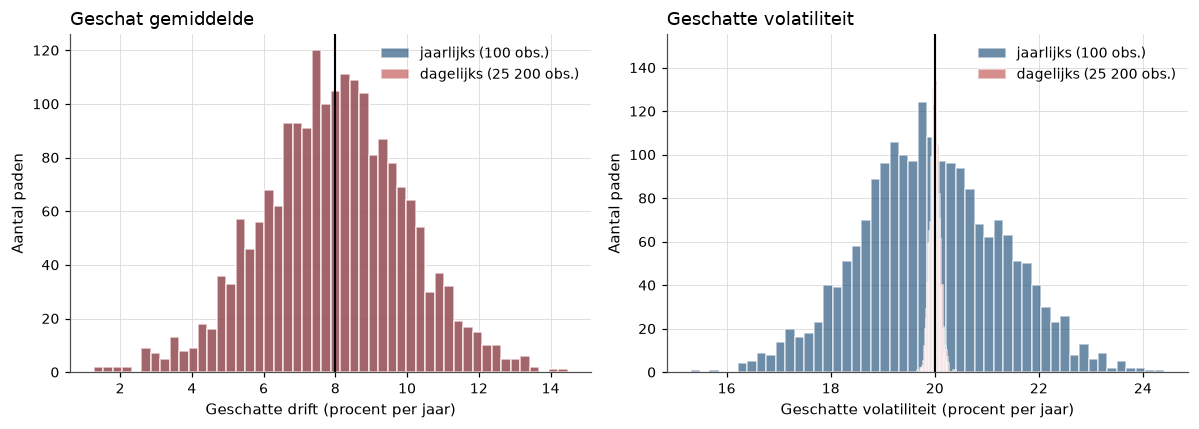

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

axes[0].hist(means["jaarlijks"] * 100, bins=50, alpha=0.65,
             label="jaarlijks (100 obs.)", edgecolor="white")
axes[0].hist(means["dagelijks"] * 100, bins=50, alpha=0.65,
             label="dagelijks (25 200 obs.)", edgecolor="white")
axes[0].axvline(nu * 100, color="black", lw=1.4)
axes[0].set_title("Geschat gemiddelde")
axes[0].set_xlabel("Geschatte drift (procent per jaar)")
axes[0].set_ylabel("Aantal paden")
axes[0].legend()

axes[1].hist(np.sqrt(variances["jaarlijks"]) * 100, bins=50, alpha=0.65,
             label="jaarlijks (100 obs.)", edgecolor="white")
axes[1].hist(np.sqrt(variances["dagelijks"]) * 100, bins=50, alpha=0.65,
             label="dagelijks (25 200 obs.)", edgecolor="white")
axes[1].axvline(sigma_true * 100, color="black", lw=1.4)
axes[1].set_title("Geschatte volatiliteit")
axes[1].set_xlabel("Geschatte volatiliteit (procent per jaar)")
axes[1].set_ylabel("Aantal paden")
axes[1].legend()

fig.tight_layout()
plt.show()

:::{figure} #cel-rendementen-frequentie
:label: fig-rendementen-frequentie
:width: 100%

Tweeduizend keer honderd jaar, twee keer bekeken. Links: de verdeling van het
geschatte gemiddelde rendement is identiek of u nu jaarlijks of dagelijks meet —
de twee histogrammen liggen exact over elkaar. Rechts: de verdeling van de
geschatte volatiliteit krimpt bij dagelijkse waarneming tot een streep. Dezelfde
paden, dezelfde honderd jaar, tweehonderdvijftig keer zoveel getallen, en alle
extra informatie gaat naar het tweede moment.
:::

Dit is de reden dat de asymmetrie geen toeval is en niet door betere methoden
weggaat. Wie een verwacht rendement wil weten heeft geschiedenis nodig, en
geschiedenis komt op één snelheid binnen.

```{warning}
Verleidelijk maar fout: "we hebben 25 200 waarnemingen, dus $t = 2$ betekent
$p < 0{,}05$". De effectieve steekproefomvang voor een uitspraak over een
gemiddeld rendement is het aantal *jaren*, niet het aantal waarnemingen. Elke
publicatie die een $t$-waarde op dagrendementen rapporteert zonder die
kanttekening, rapporteert de standaardfout van iets anders dan wat hij beweert
te meten.
```

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Lawrence Fisher & James H. Lorie, *Rates of Return on Investments in
Common Stocks*, The Journal of Business 37(1), 1964, 1–21
{cite}`FisherLorie1964`.

**Wat.** Het hoofdresultaat van het artikel: voor de gehele periode van 35 jaar
van januari 1926 tot en met december 1960 bedroeg het gemiddelde jaarlijkse
(samengestelde) rendement voor een belastingvrije belegger, mét herbelegging van
dividenden, **9,0 procent**; zonder herbelegging van dividenden 6,9 procent.
Fisher en Lorie berekenden dat voor een belegger die gelijke bedragen in elk aan
de New York Stock Exchange genoteerd gewoon aandeel stopte.

**Data hier.** Kenneth French Data Library, maandelijkse value-weighted
marktfactor via `hap.data.market_monthly()` (`Mkt = Mkt-RF + RF`), en de
equal-weighted size-decielen via
`hap.data.french("Portfolios_Formed_on_ME", "monthly", table="Equal-Weight")`.
Steekproef 1926-07 t/m 1960-12.

**Verschil met het origineel.** Drie verschillen, en ze zijn alle drie
substantieel. (1) Fisher en Lorie beginnen in januari 1926; French begint in
juli 1926, zodat wij 414 in plaats van 420 maanden hebben. (2) Fisher en Lorie
wegen gelijke *bedragen* per aandeel bij aankoop en houden vast tot het einde;
de French-portefeuilles worden maandelijks geherbalanceerd. Maandelijks
herbalanceren van kleine aandelen verhoogt het gemeten rendement aanzienlijk
(bid-ask bounce en de rebalanceringspremie), zodat wij hun constructie niet
exact kunnen nabouwen. (3) Wij hebben geen toegang tot CRSP zelf en erven de
constructiekeuzes van French, inclusief de behandeling van delistings.

**Verwachte afwijking.** Het samengestelde rendement van de value-weighted
markt over onze steekproef moet binnen ongeveer één procentpunt van de
gepubliceerde 9,0% liggen: het is dezelfde beurs, dezelfde bijna-35 jaar en
dezelfde CRSP-bron, en de ordegrootte kan niet afwijken zonder dat er een fout
in de code zit. De equal-weighted variant moet *hoger* uitkomen dan 9,0% —
kleine aandelen deden het in deze periode beter en maandelijks herbalanceren
versterkt dat — en het teken van dat verschil is het falsifieerbare deel. Komt
de equal-weighted reeks lager uit dan de value-weighted, dan klopt er iets niet.
De standaardfout van beide getallen zal ongeveer vier procentpunt zijn; die
staat niet in het artikel van 1964 en is het eigenlijke onderwerp van deze
lecture.
```

In [7]:
deciles = ["Lo 10", "2-Dec", "3-Dec", "4-Dec", "5-Dec", "6-Dec",
           "7-Dec", "8-Dec", "9-Dec", "Hi 10"]
size_ew = hap_data.french("Portfolios_Formed_on_ME", "monthly", table="Equal-Weight")

sample = slice("1926-07", "1960-12")
value_weighted = hap_data.market_monthly()["Mkt"].loc[sample]
equal_weighted = size_ew[deciles].loc[sample].mean(axis=1)


def annual_summary(returns: pd.Series) -> dict[str, float]:
    """Compounded and arithmetic annual return with the standard error."""
    n_months = len(returns)
    years = n_months / 12
    sd_ann = returns.std(ddof=1) * np.sqrt(12)
    return {
        "maanden": n_months,
        "samengesteld (meetk.)": (1 + returns).prod() ** (1 / years) - 1,
        "rekenkundig": 12 * returns.mean(),
        "volatiliteit": sd_ann,
        "SE van het gemiddelde": sd_ann / np.sqrt(years),
    }


fisher_lorie = pd.DataFrame(
    {
        "value-weighted markt": annual_summary(value_weighted),
        "equal-weighted (10 size-decielen)": annual_summary(equal_weighted),
    }
).T
fisher_lorie.round(4)

,maanden,samengesteld (meetk.),rekenkundig,volatiliteit,SE van het gemiddelde
value-weighted markt,414.0,0.0946,0.1167,0.2293,0.039
equal-weighted (10 size-decielen),414.0,0.1291,0.1699,0.3230,0.055


De value-weighted markt geeft **9,46%** samengesteld over 1926-07 t/m 1960-12,
tegen de gepubliceerde 9,0%. Een halve procentpunt verschil op een periode die
zes maanden korter is en een andere weging heeft: de replicatie slaagt binnen
de aangekondigde marge. De equal-weighted variant komt op 12,9% uit, ruim boven
9,0%, met het verwachte teken — maar ook ruim boven wat Fisher en Lorie met hun
eigen gelijke-bedragen-constructie vonden. Dat verschil van bijna vier
procentpunt is geen meetfout maar het effect van maandelijks herbalanceren in
het kleinste deciel, en het is een vroege waarschuwing dat "equal-weighted" geen
eenduidige instructie is.

En dan het getal dat in 1964 niet werd gerapporteerd. De standaardfout van het
gemiddelde is **3,9 procentpunt** voor de value-weighted reeks. Het beroemde
9,0% had dus een 95%-interval dat ongeveer van 2% tot 17% liep. De eerste
betrouwbare meting van het rendement op Amerikaanse aandelen was, als meting,
nauwelijks informatiever dan de vraag of het getal positief is.

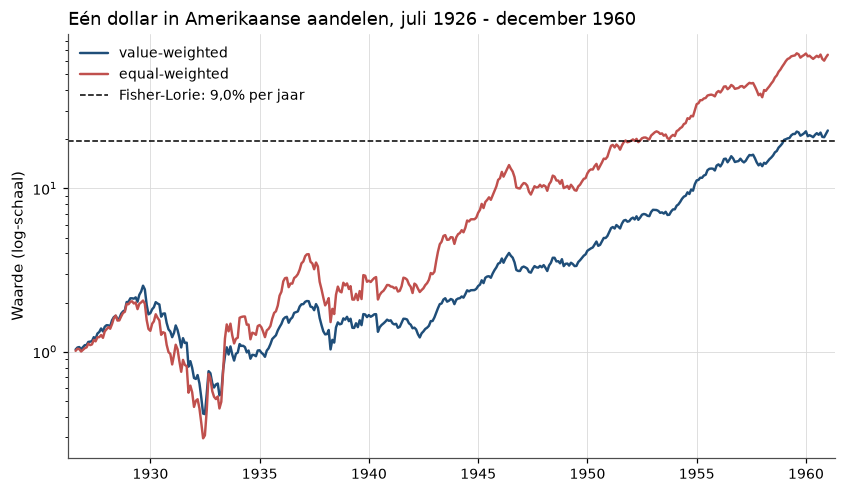

In [8]:
cumulative = pd.DataFrame(
    {"value-weighted": (1 + value_weighted).cumprod(),
     "equal-weighted": (1 + equal_weighted).cumprod()}
)

fig, ax = plt.subplots()
for column, color in zip(cumulative.columns, hap.plotting.COLORS):
    ax.plot(cumulative.index, cumulative[column], label=column, color=color)
ax.set_yscale("log")
ax.axhline(1.09 ** (len(value_weighted) / 12), color="black", ls="--", lw=1.0,
           label="Fisher-Lorie: 9,0% per jaar")
ax.set_title("Eén dollar in Amerikaanse aandelen, juli 1926 - december 1960")
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde (log-schaal)")
ax.legend()
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-rendementen-fisherlorie
:label: fig-rendementen-fisherlorie
:width: 90%

De periode die Fisher en Lorie bekeken, met de stippellijn op het eindvermogen
dat bij hun gepubliceerde 9,0% per jaar hoort. De value-weighted reeks eindigt
er vlak boven, de equal-weighted reeks ver erboven. De crash van 1929–1932 —
een terugval van meer dan 80% — zit er volledig in, en dat is precies waarom
tijdgenoten het resultaat opzienbarend vonden: zelfs met de Grote Depressie
inbegrepen was het langetermijnrendement op aandelen ruim positief.
:::

### Dezelfde eeuw, vier frequenties

Nu de stelling van Merton op echte data. We nemen de volledige French-reeks van
juli 1926 tot juli 2026, één keer op maandbasis en één keer op dagbasis, en
zetten de geannualiseerde grootheden naast elkaar.

In [9]:
market_monthly = hap_data.market_monthly()["Mkt"].rename("markt, maandelijks")
market_daily = hap_data.market_daily()["Mkt"].rename("markt, dagelijks")

comparison = pd.concat(
    [
        hap.summary_stats(market_monthly, "monthly"),
        hap.summary_stats(market_daily, "daily"),
    ]
)[["nobs", "mean_ann", "std_ann", "se_mean_ann", "skew", "kurtosis"]]
comparison.round(4)

,nobs,mean_ann,std_ann,se_mean_ann,skew,kurtosis
"markt, maandelijks",1201,0.115714,0.183371,0.018329,0.126178,7.379131
"markt, dagelijks",26296,0.108374,0.171007,0.016741,-0.166231,16.121397


Twaalfhonderd waarnemingen tegen zesentwintigduizend — tweeëntwintig keer zoveel
data — en de standaardfout van het geannualiseerde gemiddelde gaat van 1,83
procentpunt naar 1,67 procentpunt. Dat kleine verschil komt niet van het aantal
waarnemingen maar van de geschatte volatiliteit zelf, die op dagbasis lager
uitvalt (17,1% tegen 18,3%) omdat de maandreeks positieve autocorrelatie bevat.
De informatie over het gemiddelde is dezelfde. De excess kurtosis springt
intussen van 7,4 naar 16,1: de dagreeks vertelt veel meer over de staarten en
niets meer over het midden.

### Wat er wél in de data zit: clustering en de random walk

Tot slot twee diagnoses die de rest van Deel I voorbereiden. De eerste: zijn
rendementen autogecorreleerd, zodat de wortel-$t$-regel niet geldt? De tweede:
is *volatiliteit* autogecorreleerd?

In [10]:
log_daily = np.log1p(hap_data.market_daily()["Mkt"].dropna())
log_monthly = np.log1p(hap_data.market_monthly()["Mkt"].dropna())

diagnostics = pd.DataFrame(
    {
        "autocorr. rendement (dag)": [log_daily.autocorr(k) for k in range(1, 7)],
        "autocorr. |rendement| (dag)": [log_daily.abs().autocorr(k) for k in range(1, 7)],
        "autocorr. rendement (maand)": [log_monthly.autocorr(k) for k in range(1, 7)],
    },
    index=pd.Index(range(1, 7), name="lag"),
)
diagnostics.round(3)

,autocorr. rendement (dag),autocorr. |rendement| (dag),autocorr. rendement (maand)
lag,,,
1,0.047,0.299,0.085
2,-0.024,0.332,-0.022
3,0.001,0.316,-0.074
4,0.016,0.306,0.021
5,0.009,0.311,0.069
6,-0.025,0.304,-0.025


In [11]:
variance_ratios = pd.DataFrame(
    [hap.variance_ratio(log_monthly, q) for q in (2, 3, 6, 12, 24, 60)],
    index=pd.Index([2, 3, 6, 12, 24, 60], name="horizon q (maanden)"),
)[["vr", "z2", "pvalue"]]
variance_ratios.round(3)

,vr,z2,pvalue
horizon q (maanden),,,
2,1.087,1.758,0.079
3,1.102,1.409,0.159
6,1.083,0.699,0.485
12,1.188,1.070,0.285
24,1.196,0.772,0.440
60,0.971,-0.077,0.939


Het patroon is ondubbelzinnig. De autocorrelatie van het rendement zelf is bij
elke lag kleiner dan 0,09 en bij de meeste lags kleiner dan 0,03; de variance
ratios liggen tussen 0,97 en 1,20 en geen van de toetsen haalt een $p$-waarde
onder 0,05. Het rendement gedraagt zich als een random walk, precies zoals
[](#eq-rendementen-wortelt) aanneemt. De autocorrelatie van de *absolute*
rendementen is daarentegen ongeveer 0,30 bij lag 1 en nog steeds 0,30 bij lag 6:
volatiliteit klontert, dag na dag, en dat verdwijnt niet.

Daar staat de asymmetrie van deze lecture nog één keer, nu in de data in plaats
van in een formule. De grootheid die we goed kunnen meten is bovendien
voorspelbaar; de grootheid die we niet goed kunnen meten vertoont geen enkel
patroon. Dat is geen toeval maar hetzelfde feit, twee keer bekeken.

### Honderdvijftig jaar, met dezelfde conclusie

Shiller's reeks gaat terug tot 1871 en bevat de consumentenprijsindex, zodat we
naar *reële* totaalrendementen kunnen kijken. Anderhalve eeuw zou moeten helpen.

In [12]:
real_index = hap_data.shiller()["real_total_return_price"].dropna()
annual_real = real_index.resample("YE").last().pct_change().dropna()
annual_real = annual_real[annual_real.index.year <= 2025]

long_run = pd.DataFrame(
    {
        "waarde": [
            len(annual_real),
            annual_real.mean(),
            (1 + annual_real).prod() ** (1 / len(annual_real)) - 1,
            annual_real.std(ddof=1),
            annual_real.std(ddof=1) ** 2 / 2,
            annual_real.std(ddof=1) / np.sqrt(len(annual_real)),
            annual_real.kurtosis(),
            annual_real.autocorr(1),
        ]
    },
    index=["aantal jaren", "rekenkundig gemiddelde", "meetkundig gemiddelde",
           "standaarddeviatie", "halve variantie", "standaardfout van het gemiddelde",
           "excess kurtosis", "autocorrelatie lag 1"],
).round(4)
long_run

,waarde
aantal jaren,154.0000
rekenkundig gemiddelde,0.0864
meetkundig gemiddelde,0.0706
standaarddeviatie,0.1794
halve variantie,0.0161
standaardfout van het gemiddelde,0.0145
excess kurtosis,0.0131
autocorrelatie lag 1,-0.0009


Honderdvierenvijftig jaargangen reëel totaalrendement. Het rekenkundig
gemiddelde is 8,64%, het meetkundige 7,06%; het verschil van 1,58 procentpunt
staat naast een halve variantie van 1,61 procentpunt, en
[](#thm-rendementen-drag) is daarmee op honderdvijftig jaar echte data
bevestigd tot op drie honderdste procentpunt. De excess kurtosis is 0,01 —
*jaarlijkse* rendementen zijn vrijwel perfect normaal, want de dikke staarten van
de dagreeks middelen bij aggregatie uit — en de autocorrelatie is
verwaarloosbaar. De standaardfout van het gemiddelde is, na anderhalve eeuw,
1,45 procentpunt.

## Wat er brak, en wat daarna kwam

**Wat de meetlat oplevert.** Het is een compleet en sluitend apparaat. Met
[](#eq-rendementen-additief), [](#eq-rendementen-wortelt) en
[](#eq-rendementen-se) kan elke bewering over gemiddelde rendementen worden
vertaald in een uitspraak met een standaardfout ernaast, en die vertaling is
exact: geen model, geen aanname over voorkeuren, geen theorie. In deze lecture
is elke grootheid die het vak gebruikt precies gedefinieerd, en van elke
schatter is de precisie bekend. Dat is meer dan de meeste vakgebieden van hun
meetlat kunnen zeggen.

**Waar het breekt.** Precies daar waar het instrument scherp genoeg is om zijn
eigen grenzen te laten zien. De replicatie hierboven gaf het samengestelde
marktrendement over 1926–1960 als 9,46% met een standaardfout van 3,9
procentpunt, en over de volledige eeuw 11,6% met 1,8 procentpunt. Er is geen
methode, geen frequentie en geen dataset die dat verbetert, want
[](#thm-rendementen-merton) zegt dat de informatie over de drift in de
kalenderlengte zit en nergens anders. Het vak heeft dus een centrale grootheid
— het verwachte rendement, de $\E[R]$ in elke waarderingsvergelijking die nog
komt — die het niet nauwkeuriger dan op een paar procentpunt kan meten. Alles
wat in de rest van deze reeks een "puzzel" heet, is uiteindelijk een bewering
over dat getal.

**Risico of vergissing?** Deze lecture kan die vraag niet beslechten, maar ze
laat wél zien waarom hij zo hardnekkig is. Stel dat de markt in 1932 goedkoop
was. De Chicago-lezing is dat beleggers een hogere vergoeding eisten: het
verwachte rendement was toen hoger dan normaal. De Yale-lezing is dat beleggers
in paniek waren: de prijs zat ernaast. Om die twee te scheiden zou u het
verwachte rendement van 1932 moeten *meten*, apart van dat van andere jaren. De
rekensom van [](#eq-rendementen-jaren) zegt dat u voor een verschil van twee
procentpunt vierhonderd jaar nodig hebt, en u hebt er drie. De twee kampen zijn
het niet oneens over de data; ze putten uit dezelfde bron die te weinig water
geeft om beide emmers te vullen. Waar in deze reeks een lecture kiest tussen
risico en vergissing, kiest ze op grond van een model — niet op grond van een
meting, want die is er niet.

**Wat er daarna kwam.** De formules van deze lecture zijn niet in een
statistiekboek bedacht maar op een handelsvloer. In 1863 publiceerde een Parijse
beursemployé de observatie dat de gemiddelde koersuitslag met de wortel van de
verstreken tijd toeneemt — [](#eq-rendementen-wortelt), zevenendertig jaar voor
Bachelier en tweeënveertig jaar voor Einstein. Daar gaat
[](#01-02-bachelier) over: de wortel-$t$-wet als empirisch feit, de Brownse
beweging als het model erachter, en de eerste toetsen of koersen werkelijk
geheugenloos zijn.

## Oefeningen

:::{exercise}
:label: ex-rendementen-1

**De twee standaardfouten, met de hand en met de computer.**

1. Leid [](#eq-rendementen-merton) opnieuw af, maar nu zonder continue tijd:
   neem $N = nT$ onafhankelijke increments $\ell_i \sim N(\nu/n, \sigma^2/n)$ en
   toon aan dat de geannualiseerde gemiddelde-schatter
   $\hat\nu = (n/N)\sum_i \ell_i$ variantie $\sigma^2/T$ heeft, ongeacht $n$.
2. Een onderzoeker beweert dat de equity premium 6% is; een ander beweert 4%.
   Hoeveel jaar data is er nodig om die twee hypothesen met $t = 2$ te scheiden,
   bij $\sigma = 20\%$? En hoeveel bij $\sigma = 15\%$?
3. Simuleer 20 000 steekproeven van 100 jaarlijkse rendementen met
   $\mu = 6\%$ en $\sigma = 20\%$. In welke fractie van de steekproeven is de
   geschatte premie negatief? En in welke fractie haalt hij $t > 2$?
:::

:::{solution} ex-rendementen-1
:class: dropdown

**(1)** De som $\sum_{i=1}^{N}\ell_i$ heeft gemiddelde $N\nu/n = T\nu$ en
variantie $N\sigma^2/n = T\sigma^2$. De geannualiseerde schatter is
$\hat\nu = (1/T)\sum_i \ell_i$, dus $\E[\hat\nu] = \nu$ en
$\Var(\hat\nu) = T\sigma^2/T^2 = \sigma^2/T$. Er staat nergens een $n$ in het
antwoord: de frequentie valt weg omdat elk increment $n$ keer kleiner én $n$
keer minder variabel is, terwijl er $n$ keer zoveel zijn.

**(2)** $T^{*} = (t\,\Delta\mu^{-1}\sigma)^2$ met $\Delta\mu = 0{,}02$.

**(3)**

In [13]:
n_sim, n_obs, mu_ex, sigma_ex = 20_000, 100, 0.06, 0.20
draws = rng.normal(mu_ex, sigma_ex, size=(n_sim, n_obs))
sample_mean = draws.mean(axis=1)
sample_t = sample_mean / (draws.std(axis=1, ddof=1) / np.sqrt(n_obs))

pd.DataFrame(
    {
        "waarde": [
            (2 * 0.20 / 0.02) ** 2,
            (2 * 0.15 / 0.02) ** 2,
            float(np.mean(sample_mean < 0)),
            float(np.mean(sample_t > 2)),
        ]
    },
    index=["jaren nodig bij sigma=20%", "jaren nodig bij sigma=15%",
           "fractie met negatieve geschatte premie", "fractie met t > 2"],
).round(4)

,waarde
jaren nodig bij sigma=20%,400.0000
jaren nodig bij sigma=15%,225.0000
fractie met negatieve geschatte premie,0.0016
fractie met t > 2,0.8442


Vierhonderd jaar bij $\sigma = 20\%$ en tweehonderdvijfentwintig bij
$\sigma = 15\%$: geen van beide bestaat. In ongeveer 0,2% van de eeuwen komt een
onderzoeker met een perfect gespecificeerd model tot de conclusie dat aandelen
minder opbrengen dan niets, en in ongeveer 85% haalt hij $t > 2$ — dat laatste
is het onderscheidend vermogen van de toets "is de premie nul?", en het is
netjes. Het is alleen niet de vraag waar iemand het antwoord op wil weten.
:::

:::{exercise}
:label: ex-rendementen-2

**Fisher-Lorie op andere steekproeven.** Herhaal de replicatie hierboven voor
drie periodes: 1926-07 t/m 1960-12 (de originele), 1961-01 t/m 1993-12, en
1994-01 t/m 2026-07.

1. Rapporteer per periode het samengestelde en het rekenkundige jaarrendement
   van de value-weighted markt, de volatiliteit en de standaardfout van het
   gemiddelde.
2. Toets of het gemiddelde rendement van de eerste periode verschilt van dat van
   de derde. Gebruik de standaardfout van het verschil onder de aanname van
   onafhankelijkheid tussen de perioden (die aanname is hier redelijk, anders
   dan bij gelijktijdige reeksen).
3. Wat zou u moeten waarnemen om te concluderen dat de equity premium sinds
   Fisher en Lorie is veranderd?
:::

:::{solution} ex-rendementen-2
:class: dropdown

In [14]:
periods = {
    "1926-07 / 1960-12": slice("1926-07", "1960-12"),
    "1961-01 / 1993-12": slice("1961-01", "1993-12"),
    "1994-01 / 2026-07": slice("1994-01", "2026-07"),
}
market = hap_data.market_monthly()["Mkt"]

by_period = pd.DataFrame(
    {name: annual_summary(market.loc[window]) for name, window in periods.items()}
).T
by_period.round(4)

,maanden,samengesteld (meetk.),rekenkundig,volatiliteit,SE van het gemiddelde
1926-07 / 1960-12,414.0,0.0946,0.1167,0.2293,0.0390
1961-01 / 1993-12,396.0,0.1073,0.1143,0.1538,0.0268
1994-01 / 2026-07,391.0,0.1092,0.1161,0.1543,0.0270


In [15]:
first, last = by_period.index[0], by_period.index[-1]
difference = by_period.loc[first, "rekenkundig"] - by_period.loc[last, "rekenkundig"]
se_difference = np.sqrt(
    by_period.loc[first, "SE van het gemiddelde"] ** 2
    + by_period.loc[last, "SE van het gemiddelde"] ** 2
)

pd.DataFrame(
    {"waarde": [difference, se_difference, difference / se_difference,
                (2 * by_period["volatiliteit"].mean() / abs(difference)) ** 2]},
    index=["verschil in rekenkundig gemiddelde", "standaardfout van het verschil",
           "t-waarde", "jaren per periode voor t=2 bij dit verschil"],
).round(4)

,waarde
verschil in rekenkundig gemiddelde,0.0007
standaardfout van het verschil,0.0475
t-waarde,0.0137
jaren per periode voor t=2 bij dit verschil,301975.9365


Het resultaat is opmerkelijker dan verwacht. De *rekenkundige* gemiddelden van
de drie perioden zijn 11,67%, 11,43% en 11,61% — ze schelen zeven honderdste
procentpunt tussen de eerste en de laatste, en de $t$-waarde van dat verschil is
0,01. Het *samengestelde* rendement loopt wél uiteen, van 9,46% naar 10,73% en
10,92%, en dat verschil komt volledig uit [](#thm-rendementen-drag): de
volatiliteit daalde van 22,9% naar ruim 15%, en een halve variantie minder drag
is ruim één procentpunt meer eindvermogen bij hetzelfde verwachte rendement.
Wie de twee soorten gemiddelde door elkaar haalt, ziet hier een stijgende equity
premium die er niet is.

Het antwoord op (3) is ontnuchterend. Bij het waargenomen verschil zou elke
periode driehonderdduizend jaar moeten duren om $t = 2$ te halen, en zelfs voor
een verschil van twee procentpunt zijn het er bij deze volatiliteit enkele
honderden per periode. De vraag "is de equity premium veranderd sinds 1964?" is
met rendementsdata alleen niet beantwoordbaar — en dat is precies waarom Deel IV
en Deel V hem via *prijzen* (waarderingsratio's) proberen te benaderen in plaats
van via gerealiseerde rendementen.
:::

:::{exercise}
:label: ex-rendementen-3

**Aggregatie en staarten.** Neem de dagelijkse marktreeks uit
`hap_data.market_daily()`.

1. Bereken de excess kurtosis van logrendementen geaggregeerd over 1, 5, 21 en
   252 handelsdagen (niet-overlappende blokken). Wat gebeurt er?
2. Bereken voor elk van die horizonnen de relatieve standaardfout van de
   variantieschatting, één keer onder normaliteit ($\sqrt{2/N}$) en één keer met
   de waargenomen kurtosis ($\sqrt{(\kappa-1)/N}$). Hoeveel kost de dikke staart?
3. Bereken voor dezelfde horizonnen de standaardfout van het geannualiseerde
   gemiddelde. Verklaar wat u ziet met [](#thm-rendementen-merton).
:::

:::{solution} ex-rendementen-3
:class: dropdown

In [16]:
daily_log = np.log1p(hap_data.market_daily()["Mkt"].dropna())
rows = {}
for horizon in (1, 5, 21, 252):
    blocks = daily_log.to_numpy()[: len(daily_log) // horizon * horizon]
    aggregated = pd.Series(blocks.reshape(-1, horizon).sum(axis=1))
    n_obs = len(aggregated)
    excess_kurtosis = aggregated.kurtosis()
    years = n_obs * horizon / 252
    rows[f"{horizon} dagen"] = {
        "waarnemingen": n_obs,
        "excess kurtosis": excess_kurtosis,
        "rel. SE variantie, normaal": np.sqrt(2 / n_obs),
        "rel. SE variantie, waargenomen": np.sqrt((excess_kurtosis + 2) / n_obs),
        "SE gemiddelde (pp per jaar)": (
            aggregated.std(ddof=1) * np.sqrt(252 / horizon) / np.sqrt(years) * 100
        ),
    }
pd.DataFrame(rows).T.round(4)

,waarnemingen,excess kurtosis,"rel. SE variantie, normaal","rel. SE variantie, waargenomen",SE gemiddelde (pp per jaar)
1 dagen,26296.0,16.9899,0.0087,0.0269,1.6765
5 dagen,5259.0,8.4850,0.0195,0.0447,1.7203
21 dagen,1252.0,6.5570,0.0400,0.0827,1.7574
252 dagen,104.0,4.3959,0.1387,0.2480,2.0256


De excess kurtosis daalt van 17,0 op dagbasis naar 8,5, 6,6 en ten slotte 4,4 op
jaarbasis: de centrale limietstelling doet zijn werk, maar langzaam, en op
jaarbasis zijn de staarten nog altijd duidelijk dikker dan normaal. Dat is geen
tegenspraak met de Shiller-reeks hierboven, die op 154 jaargangen een excess
kurtosis van 0,01 gaf: hier zijn het er 104, en een kurtosisschatting uit
honderd waarnemingen is zelf uiterst onnauwkeurig — één 1931 of één 2008
bepaalt hem grotendeels.

De prijs van de dikke staarten zit volledig in het tweede moment. Op dagbasis is
de relatieve standaardfout van de variantieschatting 2,7% in plaats van de 0,9%
die bij normaliteit zou horen: een factor drie, precies $\sqrt{(\kappa-1)/2}$.
De standaardfout van het geannualiseerde *gemiddelde* blijft intussen bij alle
vier de horizonnen tussen 1,7 en 2,0 procentpunt, en die lichte stijging komt
niet van het aantal waarnemingen maar van de geschatte volatiliteit, die op
jaarbasis hoger uitvalt door de positieve autocorrelatie in de reeks. Dat is
[](#thm-rendementen-merton) in tabelvorm: van 26 296 naar 104 waarnemingen — een
factor 253 minder data — en de precisie van het gemiddelde verandert met een
vijfde.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->